In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("battery.csv")
df.head()

,IR,QC,QD,Tavg,Tmin,cycle_no,cycle_life,battery_name,chargetime,battery_index
0,0.016742,1.071042,1.070689,31.875011,29.566130,1,1852,b1c0,13.341250,1
1,0.016724,1.071674,1.071900,31.931490,29.604385,2,1852,b1c0,13.425777,2
2,0.016681,1.072304,1.072510,31.932603,29.744202,3,1852,b1c0,13.425167,3
3,0.016662,1.072970,1.073174,31.959322,29.644709,4,1852,b1c0,13.341442,4
4,0.016623,1.073491,1.073576,31.961062,29.752932,5,1852,b1c0,13.340835,5


In [3]:
X = df.drop(columns=["cycle_life", "battery_name", "battery_index"])
y = df["cycle_life"]
groups = df["battery_name"]

In [40]:
X.head()

,IR,QC,QD,Tavg,Tmin,cycle_no,chargetime
0,0.016742,1.071042,1.070689,31.875011,29.566130,1,13.341250
1,0.016724,1.071674,1.071900,31.931490,29.604385,2,13.425777
2,0.016681,1.072304,1.072510,31.932603,29.744202,3,13.425167
3,0.016662,1.072970,1.073174,31.959322,29.644709,4,13.341442
4,0.016623,1.073491,1.073576,31.961062,29.752932,5,13.340835


In [4]:
groups

0          b1c0
1          b1c0
2          b1c0
3          b1c0
4          b1c0
          ...  
100372    b3c45
100373    b3c45
100374    b3c45
100375    b3c45
100376    b3c45
Name: battery_name, Length: 100377, dtype: object

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
gkf = GroupKFold(n_splits=5)
for train_idx, test_idx in gkf.split(X_scaled, y, groups):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    break

In [7]:
X_train

array([[ 0.079997  ,  0.74980419,  0.75469713, ..., -1.10078546,
        -1.26003212,  0.32887479],
       [ 0.0664141 ,  0.76176857,  0.77789023, ..., -1.07540306,
        -1.2574541 ,  0.34171831],
       [ 0.0339988 ,  0.77370264,  0.78955091, ..., -0.98263374,
        -1.25487609,  0.34162563],
       ...,
       [ 0.72956227, -2.84155634, -2.87956759, ...,  0.16294562,
         3.37007991,  0.78724944],
       [ 0.66954233, -2.8461732 , -2.88199163, ..., -1.12731083,
         3.37265792,  0.73987306],
       [ 0.61736352, -2.84861663, -2.88743329, ..., -0.12880886,
         3.37523593,  0.88257706]])

In [8]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

In [9]:
print("--- Random Forest ---")
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)
print()

--- Random Forest ---
RMSE: 164.4164832480005
R2 Score: 0.8956219063491409



In [10]:
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

In [11]:
print("--- XGBoost ---")
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)
print()

--- XGBoost ---
RMSE: 140.7564108220297
R2 Score: 0.9235011339187622



In [12]:
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

In [13]:
print("--- Gradient Boosting ---")
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)
print()

--- Gradient Boosting ---
RMSE: 148.9026897106616
R2 Score: 0.9143901498839909



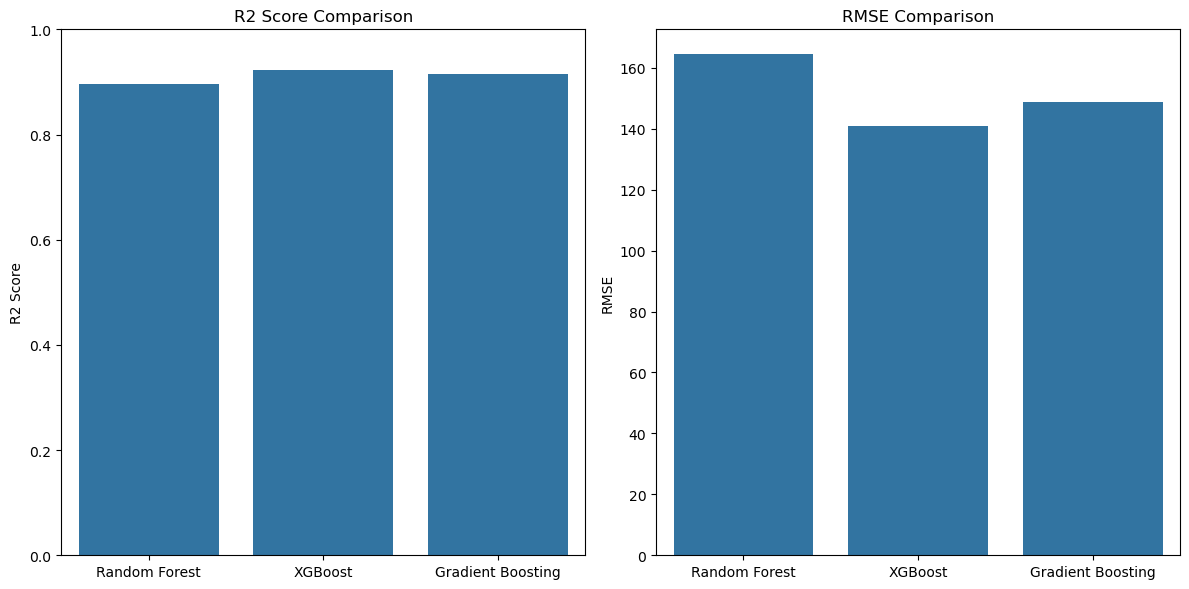

In [14]:
plt.figure(figsize=(12, 6))
model_names = ["Random Forest", "XGBoost", "Gradient Boosting"]
r2_scores = [r2_rf, r2_xgb, r2_gb]
rmse_scores = [rmse_rf, rmse_xgb, rmse_gb]

plt.subplot(1, 2, 1)
sns.barplot(x=model_names, y=r2_scores)
plt.title("R2 Score Comparison")
plt.ylabel("R2 Score")
plt.ylim(0, 1)

plt.subplot(1, 2, 2)
sns.barplot(x=model_names, y=rmse_scores)
plt.title("RMSE Comparison")
plt.ylabel("RMSE")

plt.tight_layout()
plt.show()

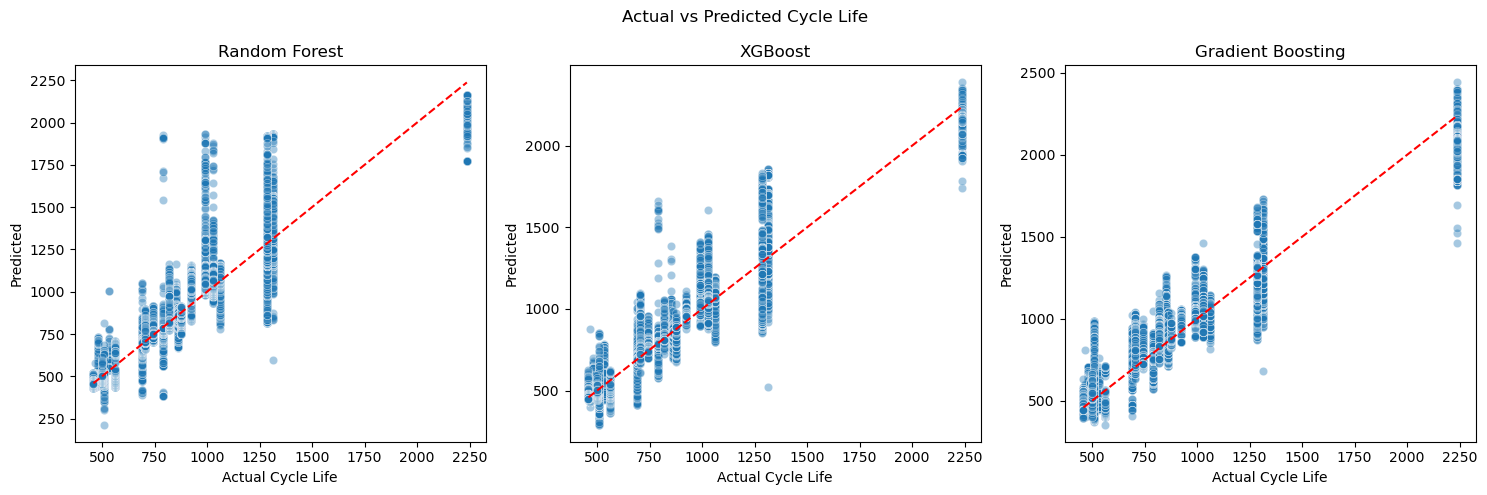

In [15]:
plt.figure(figsize=(15, 5))
models_pred = [("Random Forest", y_pred_rf), ("XGBoost", y_pred_xgb), ("Gradient Boosting", y_pred_gb)]
for i, (name, y_pred) in enumerate(models_pred, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
    plt.xlabel("Actual Cycle Life")
    plt.ylabel("Predicted")
    plt.title(name)

plt.suptitle("Actual vs Predicted Cycle Life")
plt.tight_layout()
plt.show()

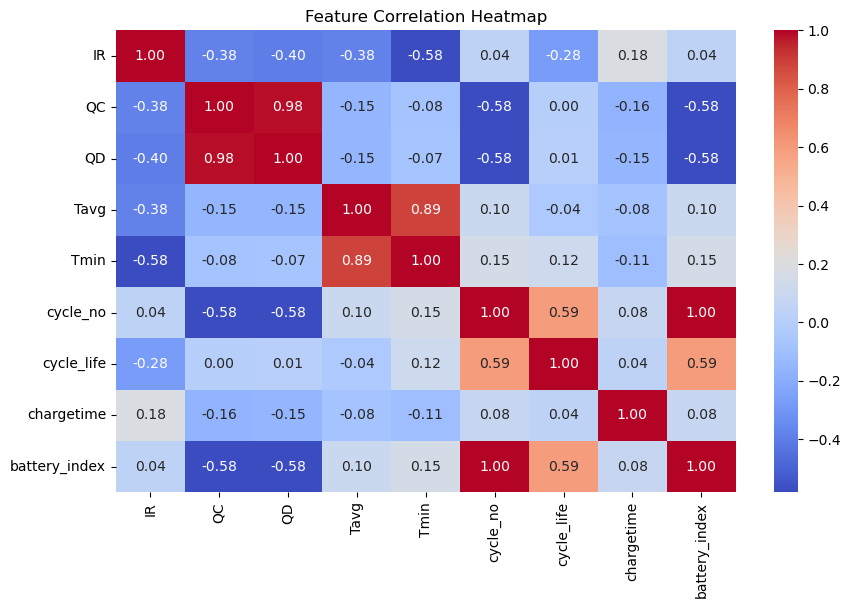

In [16]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

Best model based on R2: XGBoost


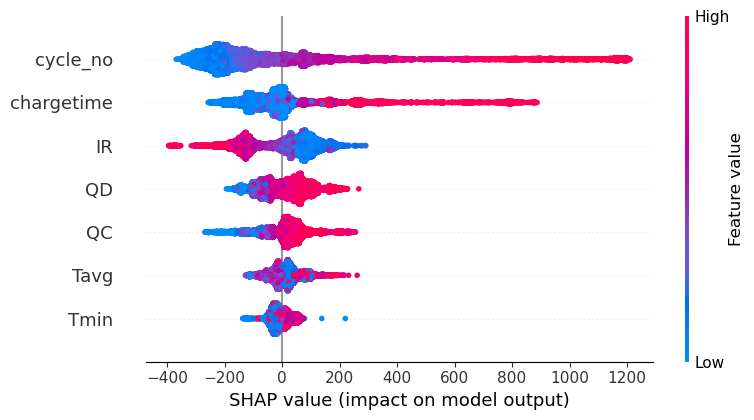

In [17]:
model_scores = {"Random Forest": r2_rf, "XGBoost": r2_xgb, "Gradient Boosting": r2_gb}
best_model_name = max(model_scores, key=model_scores.get)
best_model = rf_model if best_model_name == "Random Forest" else xgb_model if best_model_name == "XGBoost" else gb_model

print(f"Best model based on R2: {best_model_name}")

explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, features=X_test, feature_names=X.columns)

In [18]:
joblib.dump(best_model, "battery_life_predictor.pkl")

['battery_life_predictor.pkl']

In [19]:

sample_input_manual = np.array([
    [0.3, -1.1, 0.8, 0.2, -0.5, 0.0, 1.3],  
    [-0.7, 1.0, -0.3, 0.9, 0.1, -1.2, 0.5] 
])

sample_input_scaled = scaler.transform(sample_input_manual)

predicted_values = best_model.predict(sample_input_scaled)
print("\nPredictions for manually created custom input values:")
for i, pred in enumerate(predicted_values, 1):
    print(f"Custom Sample {i}: Predicted Cycle Life = {pred:.2f}")



Predictions for manually created custom input values:
Custom Sample 1: Predicted Cycle Life = 556.69
Custom Sample 2: Predicted Cycle Life = 467.92


In [42]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']